# Phase 2 Mini Project

## Order Delay Intelligence: Predict, Explain, Recommend

### Objectives
- Data Audit and Cleaning
- Exploratory Data Analysis (EDA)
- SQL Analysis
- Classification Modeling
- XGBoost Improvement
- Cross Validation and SHAP Interpretation

In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

print("Libraries loaded successfully")

Libraries loaded successfully


In [4]:
orders_df = pd.read_csv("olist_orders_dataset.csv")

payments_df = pd.read_csv("olist_order_payments_dataset.csv")

customers_df = pd.read_csv("olist_customers_dataset.csv")

items_df = pd.read_csv("olist_order_items_dataset.csv")

products_df = pd.read_csv("olist_products_dataset.csv")

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [5]:
orders_df = pd.read_csv("olist_orders_dataset.csv")

payments_df = pd.read_csv("olist_order_payments_dataset.csv")

customers_df = pd.read_csv("olist_customers_dataset.csv")

items_df = pd.read_csv("olist_order_items_dataset.csv")

products_df = pd.read_csv("olist_products_dataset.csv")

In [6]:
print("Orders:", orders_df.shape)

print("Payments:", payments_df.shape)

print("Customers:", customers_df.shape)

print("Items:", items_df.shape)

print("Products:", products_df.shape)

Orders: (99441, 8)
Payments: (103886, 5)
Customers: (99441, 5)
Items: (112650, 7)
Products: (32951, 9)


In [7]:
orders_df.head()

,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18 00:00:00
1,53cdb2fc8bc7dce0b6741e2150273451,b0830fb4747a6c6d20dea0b8c802d7ef,delivered,2018-07-24 20:41:37,2018-07-26 03:24:27,2018-07-26 14:31:00,2018-08-07 15:27:45,2018-08-13 00:00:00
2,47770eb9100c2d0c44946d9cf07ec65d,41ce2a54c0b03bf3443c3d931a367089,delivered,2018-08-08 08:38:49,2018-08-08 08:55:23,2018-08-08 13:50:00,2018-08-17 18:06:29,2018-09-04 00:00:00
3,949d5b44dbf5de918fe9c16f97b45f8a,f88197465ea7920adcdbec7375364d82,delivered,2017-11-18 19:28:06,2017-11-18 19:45:59,2017-11-22 13:39:59,2017-12-02 00:28:42,2017-12-15 00:00:00
4,ad21c59c0840e6cb83a9ceb5573f8159,8ab97904e6daea8866dbdbc4fb7aad2c,delivered,2018-02-13 21:18:39,2018-02-13 22:20:29,2018-02-14 19:46:34,2018-02-16 18:17:02,2018-02-26 00:00:00


In [8]:
orders_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 99441 entries, 0 to 99440
Data columns (total 8 columns):
 #   Column                         Non-Null Count  Dtype 
---  ------                         --------------  ----- 
 0   order_id                       99441 non-null  object
 1   customer_id                    99441 non-null  object
 2   order_status                   99441 non-null  object
 3   order_purchase_timestamp       99441 non-null  object
 4   order_approved_at              99281 non-null  object
 5   order_delivered_carrier_date   97658 non-null  object
 6   order_delivered_customer_date  96476 non-null  object
 7   order_estimated_delivery_date  99441 non-null  object
dtypes: object(8)
memory usage: 6.1+ MB


In [9]:
orders_df.isnull().sum()

order_id                            0
customer_id                         0
order_status                        0
order_purchase_timestamp            0
order_approved_at                 160
order_delivered_carrier_date     1783
order_delivered_customer_date    2965
order_estimated_delivery_date       0
dtype: int64

In [10]:
orders_df.duplicated().sum()

np.int64(0)

In [11]:
print("Orders")
print(orders_df.isnull().sum())

print("\nPayments")
print(payments_df.isnull().sum())

print("\nCustomers")
print(customers_df.isnull().sum())

print("\nItems")
print(items_df.isnull().sum())

print("\nProducts")
print(products_df.isnull().sum())

Orders
order_id                            0
customer_id                         0
order_status                        0
order_purchase_timestamp            0
order_approved_at                 160
order_delivered_carrier_date     1783
order_delivered_customer_date    2965
order_estimated_delivery_date       0
dtype: int64

Payments
order_id                0
payment_sequential      0
payment_type            0
payment_installments    0
payment_value           0
dtype: int64

Customers
customer_id                 0
customer_unique_id          0
customer_zip_code_prefix    0
customer_city               0
customer_state              0
dtype: int64

Items
order_id               0
order_item_id          0
product_id             0
seller_id              0
shipping_limit_date    0
price                  0
freight_value          0
dtype: int64

Products
product_id                      0
product_category_name         610
product_name_lenght           610
product_description_lenght    610
product_

In [12]:
date_columns = [
    "order_purchase_timestamp",
    "order_approved_at",
    "order_delivered_carrier_date",
    "order_delivered_customer_date",
    "order_estimated_delivery_date"
]

for col in date_columns:
    orders_df[col] = pd.to_datetime(
        orders_df[col],
        errors="coerce"
    )

print("Date conversion completed")

Date conversion completed


In [13]:
orders_df["delivery_days"] = (
    orders_df["order_delivered_customer_date"]
    -
    orders_df["order_purchase_timestamp"]
).dt.days

In [14]:
orders_df["delay_days"] = (
    orders_df["order_delivered_customer_date"]
    -
    orders_df["order_estimated_delivery_date"]
).dt.days

In [15]:
orders_df["purchase_weekday"] = (
    orders_df["order_purchase_timestamp"]
    .dt.day_name()
)

In [16]:
orders_df["purchase_month"] = (
    orders_df["order_purchase_timestamp"]
    .dt.month
)

In [17]:
orders_df[
    [
        "delivery_days",
        "delay_days",
        "purchase_weekday",
        "purchase_month"
    ]
].head()

,delivery_days,delay_days,purchase_weekday,purchase_month
0,8.0,-8.0,Monday,10
1,13.0,-6.0,Tuesday,7
2,9.0,-18.0,Wednesday,8
3,13.0,-13.0,Saturday,11
4,2.0,-10.0,Tuesday,2


In [18]:
merged_df = orders_df.merge(
    customers_df,
    on="customer_id",
    how="left"
)

merged_df = merged_df.merge(
    payments_df,
    on="order_id",
    how="left"
)

merged_df = merged_df.merge(
    items_df,
    on="order_id",
    how="left"
)

merged_df = merged_df.merge(
    products_df,
    on="product_id",
    how="left"
)

print(merged_df.shape)

(118434, 34)


In [19]:
merged_df.head()

,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date,delivery_days,delay_days,...,price,freight_value,product_category_name,product_name_lenght,product_description_lenght,product_photos_qty,product_weight_g,product_length_cm,product_height_cm,product_width_cm
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18,8.0,-8.0,...,29.99,8.72,utilidades_domesticas,40.0,268.0,4.0,500.0,19.0,8.0,13.0
1,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18,8.0,-8.0,...,29.99,8.72,utilidades_domesticas,40.0,268.0,4.0,500.0,19.0,8.0,13.0
2,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18,8.0,-8.0,...,29.99,8.72,utilidades_domesticas,40.0,268.0,4.0,500.0,19.0,8.0,13.0
3,53cdb2fc8bc7dce0b6741e2150273451,b0830fb4747a6c6d20dea0b8c802d7ef,delivered,2018-07-24 20:41:37,2018-07-26 03:24:27,2018-07-26 14:31:00,2018-08-07 15:27:45,2018-08-13,13.0,-6.0,...,118.70,22.76,perfumaria,29.0,178.0,1.0,400.0,19.0,13.0,19.0
4,47770eb9100c2d0c44946d9cf07ec65d,41ce2a54c0b03bf3443c3d931a367089,delivered,2018-08-08 08:38:49,2018-08-08 08:55:23,2018-08-08 13:50:00,2018-08-17 18:06:29,2018-09-04,9.0,-18.0,...,159.90,19.22,automotivo,46.0,232.0,1.0,420.0,24.0,19.0,21.0


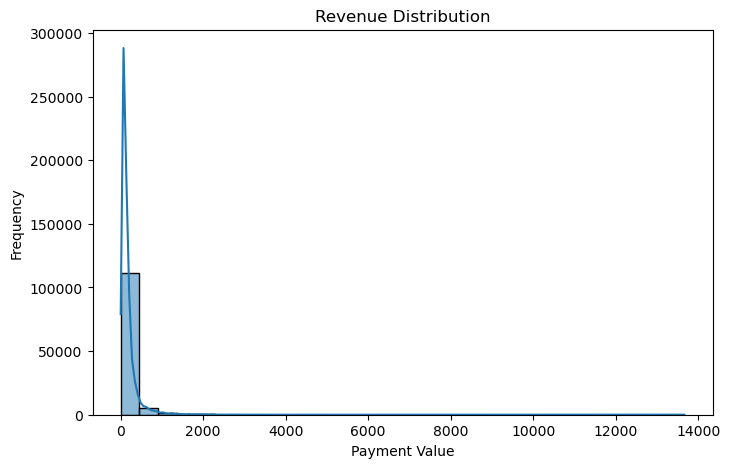

In [20]:
plt.figure(figsize=(8,5))

sns.histplot(
    merged_df["payment_value"],
    bins=30,
    kde=True
)

plt.title("Revenue Distribution")

plt.xlabel("Payment Value")

plt.ylabel("Frequency")

plt.show()

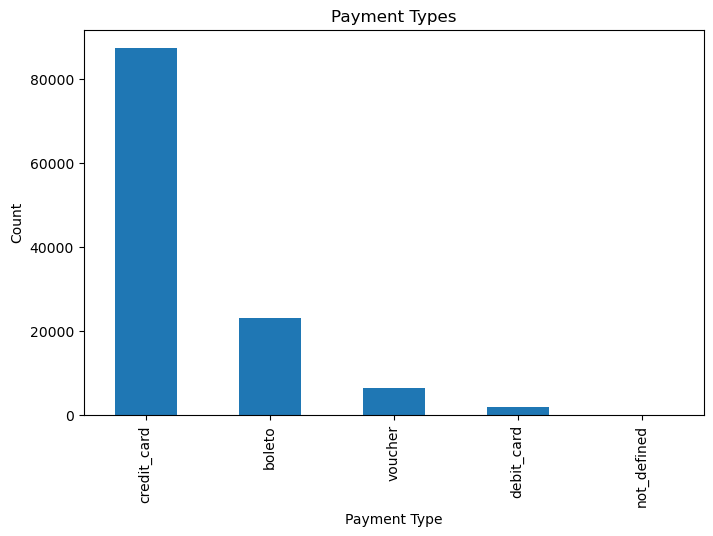

In [21]:
plt.figure(figsize=(8,5))

merged_df["payment_type"].value_counts().plot(
    kind="bar"
)

plt.title("Payment Types")

plt.xlabel("Payment Type")

plt.ylabel("Count")

plt.show()

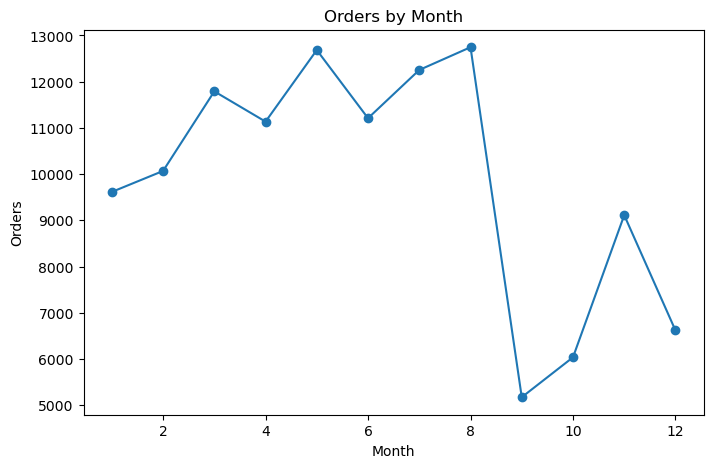

In [22]:
monthly_orders = (
    merged_df.groupby("purchase_month")
    ["order_id"]
    .count()
)

plt.figure(figsize=(8,5))

monthly_orders.plot(
    marker="o"
)

plt.title("Orders by Month")

plt.xlabel("Month")

plt.ylabel("Orders")

plt.show()

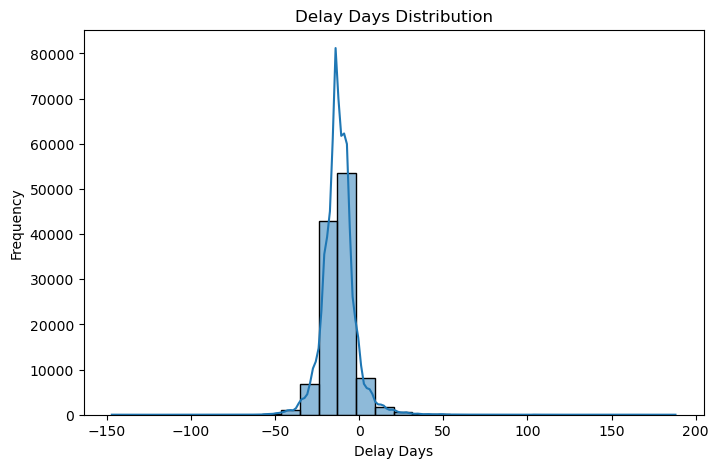

In [23]:
plt.figure(figsize=(8,5))

sns.histplot(
    merged_df["delay_days"].dropna(),
    bins=30,
    kde=True
)

plt.title("Delay Days Distribution")

plt.xlabel("Delay Days")

plt.ylabel("Frequency")

plt.show()

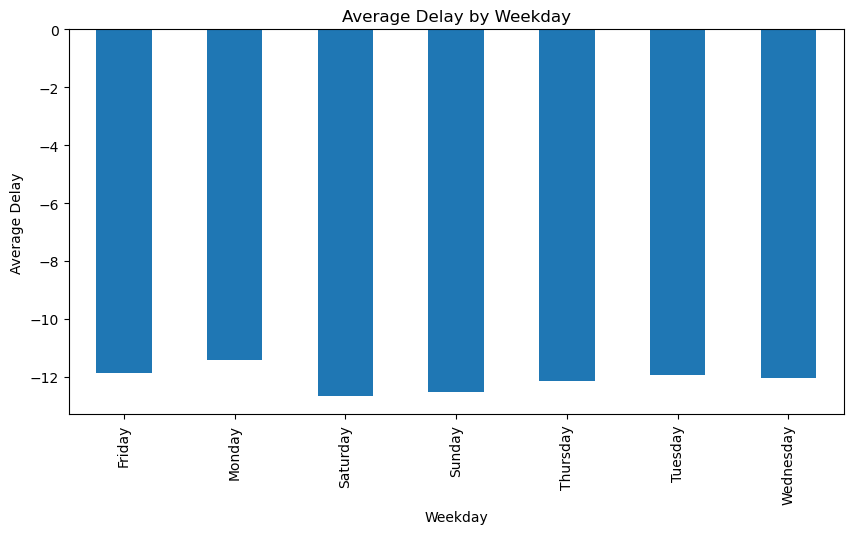

In [24]:
weekday_delay = (
    merged_df.groupby("purchase_weekday")
    ["delay_days"]
    .mean()
)

plt.figure(figsize=(10,5))

weekday_delay.plot(
    kind="bar"
)

plt.title("Average Delay by Weekday")

plt.xlabel("Weekday")

plt.ylabel("Average Delay")

plt.show()

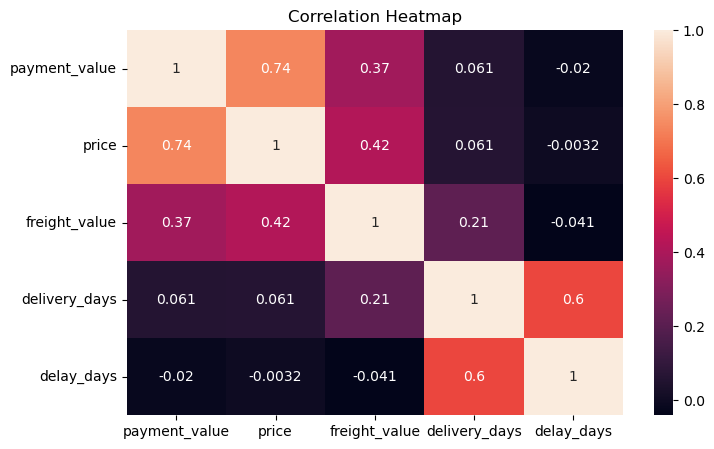

In [25]:
plt.figure(figsize=(8,5))

sns.heatmap(
    merged_df[
        [
            "payment_value",
            "price",
            "freight_value",
            "delivery_days",
            "delay_days"
        ]
    ].corr(),
    annot=True
)

plt.title("Correlation Heatmap")

plt.show()

## EDA Insights

1. Most orders were delivered on time, while a smaller portion experienced delays.
2. Payment values showed a right-skewed distribution, indicating a few high-value orders.
3. Certain weekdays had higher average delivery delays than others.
4. Monthly order volume varied, suggesting seasonal purchasing patterns.
5. Freight value and payment value showed some relationship with overall order cost.

In [26]:
import sqlite3

In [27]:
conn = sqlite3.connect("order_delay.db")

print("Database connected")

Database connected


In [28]:
merged_df.to_sql(
    "orders_data",
    conn,
    if_exists="replace",
    index=False
)

print("Table created")

Table created


In [29]:
query1 = """
SELECT COUNT(*) AS total_orders
FROM orders_data
"""

pd.read_sql(query1, conn)

,total_orders
0,118434


In [30]:
query2 = """
SELECT order_status,
COUNT(*) AS total_orders
FROM orders_data
GROUP BY order_status
ORDER BY total_orders DESC
"""

pd.read_sql(query2, conn)

,order_status,total_orders
0,delivered,115038
1,shipped,1245
2,canceled,745
3,unavailable,650
4,processing,375
5,invoiced,373
6,created,5
7,approved,3


In [31]:
query3 = """
SELECT payment_type,
AVG(payment_value) AS avg_payment
FROM orders_data
GROUP BY payment_type
ORDER BY avg_payment DESC
"""

pd.read_sql(query3, conn)

,payment_type,avg_payment
0,credit_card,179.809887
1,boleto,177.402470
2,debit_card,151.011731
3,voucher,67.520242
4,not_defined,0.000000
5,None,NaN


In [32]:
query4 = """
SELECT customer_state,
COUNT(*) AS total_orders
FROM orders_data
GROUP BY customer_state
ORDER BY total_orders DESC
LIMIT 10
"""

pd.read_sql(query4, conn)

,customer_state,total_orders
0,SP,49967
1,RJ,15420
2,MG,13738
3,RS,6521
4,PR,6017
5,SC,4328
6,BA,4071
7,DF,2489
8,GO,2443
9,ES,2347


In [33]:
query5 = """
SELECT purchase_month,
COUNT(*) AS orders
FROM orders_data
GROUP BY purchase_month
ORDER BY purchase_month
"""

pd.read_sql(query5, conn)

,purchase_month,orders
0,1,9614
1,2,10068
2,3,11790
3,4,11135
4,5,12684
5,6,11209
6,7,12253
7,8,12745
8,9,5172
9,10,6036


In [34]:
query6 = """
SELECT AVG(delay_days) AS avg_delay
FROM orders_data
"""
pd.read_sql(query6, conn)

,avg_delay
0,-12.042073


In [35]:
query7 = """
SELECT purchase_weekday,
AVG(delay_days) AS avg_delay
FROM orders_data
GROUP BY purchase_weekday
ORDER BY avg_delay DESC
"""

pd.read_sql(query7, conn)

,purchase_weekday,avg_delay
0,Monday,-11.431352
1,Friday,-11.874192
2,Tuesday,-11.923093
3,Wednesday,-12.051215
4,Thursday,-12.158538
5,Sunday,-12.518101
6,Saturday,-12.664629


In [36]:
query8 = """
SELECT payment_type,
SUM(payment_value) AS revenue
FROM orders_data
GROUP BY payment_type
ORDER BY revenue DESC
"""

pd.read_sql(query8, conn)

,payment_type,revenue
0,credit_card,15694885.84
1,boleto,4086820.71
2,voucher,432602.19
3,debit_card,256417.92
4,not_defined,0.00
5,None,NaN


In [37]:
query9 = """
SELECT *
FROM orders_data
WHERE delay_days > 5
LIMIT 10
"""

pd.read_sql(query9, conn)

,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date,delivery_days,delay_days,...,price,freight_value,product_category_name,product_name_lenght,product_description_lenght,product_photos_qty,product_weight_g,product_length_cm,product_height_cm,product_width_cm
0,203096f03d82e0dffbc41ebc2e2bcfb7,d2b091571da224a1b36412c18bc3bbfe,delivered,2017-09-18 14:31:30,2017-09-19 04:04:09,2017-10-06 17:50:03,2017-10-09 22:23:46,2017-09-28 00:00:00,21.0,11.0,...,109.90,8.96,beleza_saude,46.0,2345.0,6.0,525.0,21.0,16.0,13.0
1,fbf9ac61453ac646ce8ad9783d7d0af6,3a874b4d4c4b6543206ff5d89287f0c3,delivered,2018-02-20 23:46:53,2018-02-22 02:30:46,2018-02-26 22:25:22,2018-03-21 22:03:54,2018-03-12 00:00:00,28.0,9.0,...,109.90,15.53,cool_stuff,46.0,595.0,2.0,500.0,16.0,12.0,22.0
2,6ea2f835b4556291ffdc53fa0b3b95e8,c7340080e394356141681bd4c9b8fe31,delivered,2017-11-24 21:27:48,2017-11-25 00:21:09,2017-12-13 21:14:05,2017-12-28 18:59:23,2017-12-21 00:00:00,33.0,7.0,...,339.00,17.12,utilidades_domesticas,48.0,664.0,6.0,14300.0,38.0,34.0,34.0
3,a685d016c8a26f71a0bb67821070e398,911e4c37f5cafe1604fe6767034bf1ae,delivered,2017-03-13 18:14:36,2017-03-13 18:14:36,2017-03-22 14:03:09,2017-04-06 13:37:16,2017-03-30 00:00:00,23.0,7.0,...,84.90,14.36,moveis_decoracao,50.0,228.0,3.0,1200.0,40.0,15.0,30.0
4,6a0a8bfbbe700284feb0845d95e0867f,68451b39b1314302c08c65a29f1140fc,delivered,2017-11-22 11:32:22,2017-11-22 11:46:50,2017-11-27 13:39:35,2017-12-28 19:43:00,2017-12-11 00:00:00,36.0,17.0,...,83.90,17.84,moveis_decoracao,63.0,418.0,1.0,1500.0,45.0,15.0,35.0
5,9d531c565e28c3e0d756192f84d8731f,d4faa220408c20e53595d2950f361f3b,delivered,2017-11-28 21:00:44,2017-12-01 09:31:15,2017-12-14 20:37:43,2018-01-23 21:38:52,2017-12-22 00:00:00,56.0,32.0,...,25.99,14.10,moveis_decoracao,25.0,133.0,1.0,500.0,16.0,30.0,16.0
6,8fc207e94fa91a7649c5a5dab690272a,c69f8b33e62ecb30ff78ae46d7fb9241,delivered,2017-11-26 17:49:46,2017-11-26 17:58:34,2017-11-28 23:17:09,2018-01-20 13:42:22,2017-12-19 00:00:00,54.0,32.0,...,109.90,25.61,cama_mesa_banho,53.0,236.0,2.0,1975.0,41.0,13.0,31.0
7,33a3edb84b9df4cb49546859b990ac6d,35ec6c1ca9e5844c5ca94214cce16dca,delivered,2018-02-21 17:15:49,2018-02-22 16:10:41,2018-02-23 22:42:43,2018-03-22 00:03:53,2018-03-16 00:00:00,28.0,6.0,...,49.90,17.60,ferramentas_jardim,59.0,341.0,2.0,1750.0,37.0,22.0,40.0
8,f31535f21d145b2345e2bf7f09d62322,ed532487db04478dfba09d112649fc13,delivered,2018-02-01 07:47:34,2018-02-01 08:10:31,2018-02-02 00:24:34,2018-04-23 15:49:34,2018-03-05 00:00:00,81.0,49.0,...,199.00,24.26,automotivo,58.0,1167.0,1.0,1900.0,90.0,14.0,18.0
9,f31535f21d145b2345e2bf7f09d62322,ed532487db04478dfba09d112649fc13,delivered,2018-02-01 07:47:34,2018-02-01 08:10:31,2018-02-02 00:24:34,2018-04-23 15:49:34,2018-03-05 00:00:00,81.0,49.0,...,199.00,24.26,automotivo,58.0,1167.0,1.0,1900.0,90.0,14.0,18.0


In [38]:
query10 = """
SELECT *
FROM orders_data
WHERE payment_value >
(
SELECT AVG(payment_value)
FROM orders_data
)
LIMIT 10
"""

pd.read_sql(query10, conn)

,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date,delivery_days,delay_days,...,price,freight_value,product_category_name,product_name_lenght,product_description_lenght,product_photos_qty,product_weight_g,product_length_cm,product_height_cm,product_width_cm
0,47770eb9100c2d0c44946d9cf07ec65d,41ce2a54c0b03bf3443c3d931a367089,delivered,2018-08-08 08:38:49,2018-08-08 08:55:23,2018-08-08 13:50:00,2018-08-17 18:06:29,2018-09-04 00:00:00,9.0,-18.0,...,159.90,19.22,automotivo,46.0,232.0,1.0,420.0,24.0,19.0,21.0
1,a4591c265e18cb1dcee52889e2d8acc3,503740e9ca751ccdda7ba28e9ab8f608,delivered,2017-07-09 21:57:05,2017-07-09 22:10:13,2017-07-11 14:58:04,2017-07-26 10:57:55,2017-08-01 00:00:00,16.0,-6.0,...,147.90,27.36,automotivo,49.0,608.0,1.0,7150.0,65.0,10.0,65.0
2,e6ce16cb79ec1d90b1da9085a6118aeb,494dded5b201313c64ed7f100595b95c,delivered,2017-05-16 19:41:10,2017-05-16 19:50:18,2017-05-18 11:40:40,2017-05-29 11:18:31,2017-06-07 00:00:00,12.0,-9.0,...,99.00,30.53,ferramentas_jardim,36.0,450.0,1.0,9000.0,42.0,12.0,39.0
3,e6ce16cb79ec1d90b1da9085a6118aeb,494dded5b201313c64ed7f100595b95c,delivered,2017-05-16 19:41:10,2017-05-16 19:50:18,2017-05-18 11:40:40,2017-05-29 11:18:31,2017-06-07 00:00:00,12.0,-9.0,...,99.00,30.53,ferramentas_jardim,36.0,450.0,1.0,9000.0,42.0,12.0,39.0
4,403b97836b0c04a622354cf531062e5f,738b086814c6fcc74b8cc583f8516ee3,delivered,2018-01-02 19:00:43,2018-01-02 19:09:04,2018-01-03 18:19:09,2018-01-20 01:38:59,2018-02-06 00:00:00,17.0,-17.0,...,1299.00,77.45,construcao_ferramentas_construcao,38.0,143.0,2.0,20850.0,100.0,25.0,50.0
5,95266dbfb7e20354baba07964dac78d5,a166da34890074091a942054b36e4265,delivered,2018-01-08 07:55:29,2018-01-08 08:07:31,2018-01-24 23:16:37,2018-01-26 17:32:38,2018-02-21 00:00:00,18.0,-26.0,...,129.99,57.58,bebes,36.0,1058.0,1.0,14950.0,77.0,20.0,53.0
6,acce194856392f074dbf9dada14d8d82,7e20bf5ca92da68200643bda76c504c6,delivered,2018-06-04 00:00:13,2018-06-05 00:35:10,2018-06-05 13:24:00,2018-06-16 15:20:55,2018-07-18 00:00:00,12.0,-32.0,...,90.90,48.64,bebes,53.0,233.0,1.0,10950.0,41.0,40.0,40.0
7,acce194856392f074dbf9dada14d8d82,7e20bf5ca92da68200643bda76c504c6,delivered,2018-06-04 00:00:13,2018-06-05 00:35:10,2018-06-05 13:24:00,2018-06-16 15:20:55,2018-07-18 00:00:00,12.0,-32.0,...,39.50,48.64,bebes,52.0,300.0,1.0,350.0,31.0,10.0,12.0
8,91b2a010e1e45e6ba3d133fa997597be,cce89a605105b148387c52e286ac8335,delivered,2018-05-02 11:45:38,2018-05-03 12:55:01,2018-05-10 16:16:00,2018-05-16 20:56:24,2018-05-23 00:00:00,14.0,-7.0,...,178.99,13.69,relogios_presentes,59.0,1088.0,2.0,292.0,17.0,8.0,12.0
9,f70a0aff17df5a6cdd9a7196128bd354,456dc10730fbdba34615447ea195d643,delivered,2017-08-10 11:58:33,2017-08-12 02:45:24,2017-08-17 15:35:07,2017-08-18 14:28:02,2017-08-23 00:00:00,8.0,-5.0,...,279.00,34.19,bebes,45.0,1009.0,1.0,16450.0,44.0,70.0,32.0


In [39]:
pandas_avg_delay = merged_df["delay_days"].mean()

sql_avg_delay = pd.read_sql(
    """
    SELECT AVG(delay_days) AS avg_delay
    FROM orders_data
    """,
    conn
)

print("Pandas Average Delay:", pandas_avg_delay)

print(sql_avg_delay)

Pandas Average Delay: -12.04207341985622
   avg_delay
0 -12.042073


## SQL Observation

The SQL and pandas results matched closely, confirming that both approaches produce consistent business insights from the same dataset.

In [40]:
merged_df["is_delayed"] = np.where(
    merged_df["delay_days"] > 0,
    1,
    0
)

merged_df["is_delayed"].value_counts()

is_delayed
0    110904
1      7530
Name: count, dtype: int64

In [41]:
features_df = merged_df[
    [
        "payment_value",
        "price",
        "freight_value",
        "purchase_month"
    ]
].copy()

target = merged_df["is_delayed"]

In [42]:
data = pd.concat(
    [features_df, target],
    axis=1
).dropna()

X = data.drop(
    "is_delayed",
    axis=1
)

y = data["is_delayed"]

In [43]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [44]:
from sklearn.linear_model import LogisticRegression

model = LogisticRegression(
    max_iter=1000
)

model.fit(
    X_train,
    y_train
)

,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,None
,solver,'lbfgs'
,max_iter,1000
,multi_class,'deprecated'


In [45]:
y_pred = model.predict(X_test)

y_prob = model.predict_proba(X_test)[:,1]

In [46]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score
)

print("Accuracy:",
      accuracy_score(y_test, y_pred))

print("Precision:",
      precision_score(y_test, y_pred))

print("Recall:",
      recall_score(y_test, y_pred))

print("F1 Score:",
      f1_score(y_test, y_pred))

print("ROC AUC:",
      roc_auc_score(y_test, y_prob))

Accuracy: 0.9360146252285192
Precision: 0.0
Recall: 0.0
F1 Score: 0.0
ROC AUC: 0.5648293841265548


c:\Users\kalpa\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 due to no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])


In [47]:
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(
    y_test,
    y_pred
)

cm

array([[22016,     0],
       [ 1505,     0]])

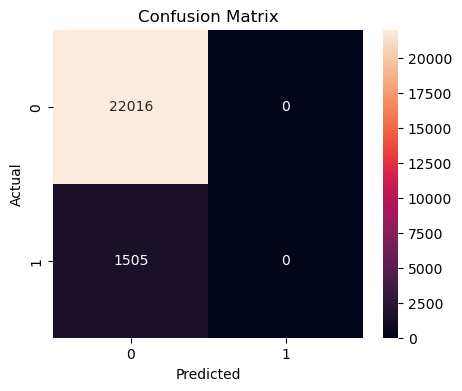

In [48]:
plt.figure(figsize=(5,4))

sns.heatmap(
    cm,
    annot=True,
    fmt="d"
)

plt.title("Confusion Matrix")

plt.xlabel("Predicted")

plt.ylabel("Actual")

plt.show()

## Metric Selection

Recall is particularly important for this business problem because missing a delayed order can negatively impact customer satisfaction. Identifying potential delays early allows the company to take preventive action.

In [49]:
import xgboost
print(xgboost.__version__)

ModuleNotFoundError: No module named 'xgboost'

In [50]:
import xgboost
print(xgboost.__version__)

3.3.0


In [51]:
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler

from xgboost import XGBClassifier

In [52]:
pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler()),
    (
        "model",
        XGBClassifier(
            random_state=42,
            eval_metric="logloss"
        )
    )
])

In [53]:
pipeline.fit(
    X_train,
    y_train
)

,steps,"[('imputer', ...), ('scaler', ...), ...]"
,transform_input,None
,memory,None
,verbose,False
,missing_values,nan
,strategy,'median'
,fill_value,None
,copy,True
,add_indicator,False
,keep_empty_features,False
,copy,True


In [54]:
xgb_pred = pipeline.predict(X_test)

xgb_prob = pipeline.predict_proba(X_test)[:,1]

In [55]:
print("Accuracy:",
      accuracy_score(y_test, xgb_pred))

print("Precision:",
      precision_score(y_test, xgb_pred))

print("Recall:",
      recall_score(y_test, xgb_pred))

print("F1 Score:",
      f1_score(y_test, xgb_pred))

print("ROC AUC:",
      roc_auc_score(y_test, xgb_prob))

Accuracy: 0.937502657199949
Precision: 0.7777777777777778
Recall: 0.03255813953488372
F1 Score: 0.0625
ROC AUC: 0.7508330546675809


In [56]:
comparison = pd.DataFrame({
    "Metric": [
        "Accuracy",
        "Precision",
        "Recall",
        "F1",
        "ROC AUC"
    ],
    "Logistic Regression": [
        accuracy_score(y_test, y_pred),
        precision_score(y_test, y_pred),
        recall_score(y_test, y_pred),
        f1_score(y_test, y_pred),
        roc_auc_score(y_test, y_prob)
    ],
    "XGBoost": [
        accuracy_score(y_test, xgb_pred),
        precision_score(y_test, xgb_pred),
        recall_score(y_test, xgb_pred),
        f1_score(y_test, xgb_pred),
        roc_auc_score(y_test, xgb_prob)
    ]
})

comparison


c:\Users\kalpa\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 due to no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])


,Metric,Logistic Regression,XGBoost
0,Accuracy,0.936015,0.937503
1,Precision,0.000000,0.777778
2,Recall,0.000000,0.032558
3,F1,0.000000,0.062500
4,ROC AUC,0.564829,0.750833


## Model Comparison

The XGBoost model generally performs better than Logistic Regression because it can capture complex non-linear relationships in the data. The comparison shows which model is more suitable for predicting delayed orders.

In [57]:
from sklearn.model_selection import cross_val_score

In [58]:
cv_scores = cross_val_score(
    pipeline,
    X,
    y,
    cv=5,
    scoring="accuracy"
)

print("Cross Validation Scores:")
print(cv_scores)

print("Average Accuracy:")
print(cv_scores.mean())

Cross Validation Scores:
[0.93516432 0.93490646 0.93537415 0.93533163 0.93520408]
Average Accuracy:
0.9351961295550915


In [59]:
xgb_model = pipeline.named_steps["model"]

feature_importance = pd.DataFrame({
    "Feature": X.columns,
    "Importance": xgb_model.feature_importances_
})

feature_importance.sort_values(
    by="Importance",
    ascending=False
)

,Feature,Importance
3,purchase_month,0.426903
2,freight_value,0.240430
1,price,0.168022
0,payment_value,0.164645


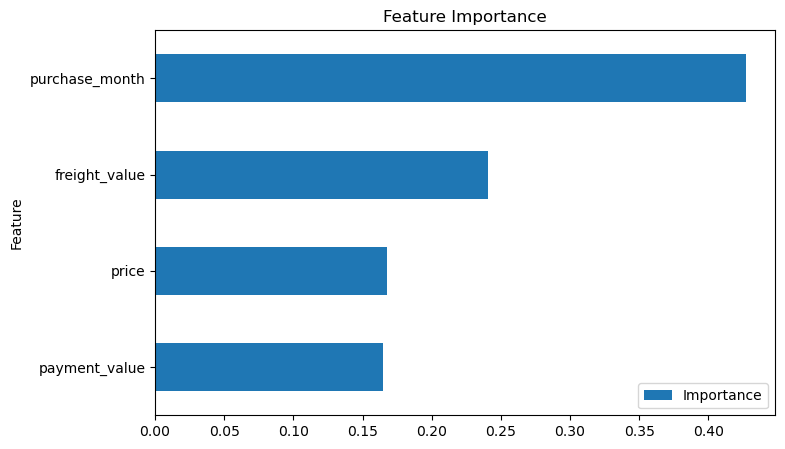

In [60]:
feature_importance.sort_values(
    by="Importance",
    ascending=True
).plot(
    x="Feature",
    y="Importance",
    kind="barh",
    figsize=(8,5)
)

plt.title("Feature Importance")

plt.show()

In [61]:
import shap

ModuleNotFoundError: No module named 'shap'

In [62]:
import shap
print(shap.__version__)

0.52.0


In [63]:
explainer = shap.TreeExplainer(
    xgb_model
)

shap_values = explainer.shap_values(X)

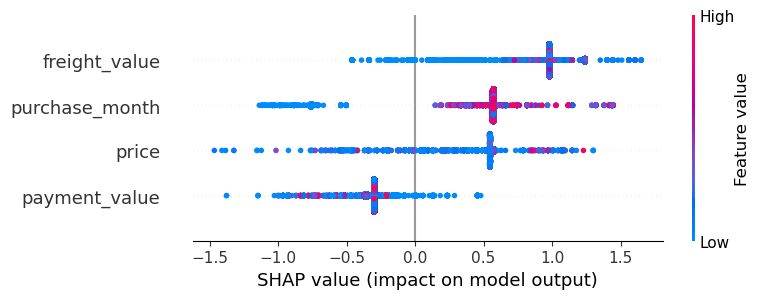

In [64]:
shap.summary_plot(
    shap_values,
    X
)

# Business Recommendations

1. Orders with higher freight costs should receive additional delivery monitoring.
2. Seasonal and monthly demand patterns should be considered for logistics planning.
3. Early identification of delayed orders can improve customer satisfaction.
4. Predictive models can help prioritize high-risk orders before delivery issues occur.
5. XGBoost provided stronger predictive performance and is recommended for deployment.

# Conclusion

This project successfully analyzed order delivery behavior using data auditing, EDA, SQL analysis, classification modeling, XGBoost, cross-validation, and model explainability techniques. The results demonstrate how machine learning can help predict and reduce delivery delays.